<a href="https://colab.research.google.com/github/likhith040/likhithsrao/blob/main/kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username": "kanilkumar11", "key": "KGAT_29f2b170c1d9e62e8162aba84a908195"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d sujithmandala/simple-rainfall-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/sujithmandala/simple-rainfall-classification-dataset
License(s): CC-BY-SA-4.0
100% 804/804 [00:00<00:00, 2.47MB/s]



In [ ]:
!unzip simple-rainfall-classification-dataset.zip

Archive:  simple-rainfall-classification-dataset.zip
  inflating: rainfall.csv            


In [ ]:
!ls

kaggle.json   sample_data
rainfall.csv  simple-rainfall-classification-dataset.zip


In [ ]:
#load dataset into pandas
import pandas as pd
df=pd.read_csv('rainfall.csv')
df.head()

,date,rainfall,temperature,humidity,wind_speed,weather_condition
0,2022-01-01,12.5,15.2,78.0,8.5,Rainy
1,2022-01-02,8.2,17.8,65.0,5.2,Rainy
2,2022-01-03,0.0,20.1,52.0,3.1,Sunny
3,2022-01-04,3.7,18.6,71.0,6.7,Rainy
4,2022-01-05,21.1,14.8,82.0,9.3,Rainy


In [ ]:
import pandas as pd
df=pd.read_csv('rainfall.csv')
df.shape
df.columns

Index(['date', 'rainfall', 'temperature', 'humidity', 'wind_speed',
       'weather_condition'],
      dtype='object')

In [ ]:
df.dtypes

,0
date,object
rainfall,float64
temperature,float64
humidity,float64
wind_speed,float64
weather_condition,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               54 non-null     object 
 1   rainfall           53 non-null     float64
 2   temperature        53 non-null     float64
 3   humidity           53 non-null     float64
 4   wind_speed         53 non-null     float64
 5   weather_condition  53 non-null     object 
dtypes: float64(4), object(2)
memory usage: 2.7+ KB


In [ ]:
df.isnull().sum()

,0
date,0
rainfall,1
temperature,1
humidity,1
wind_speed,1
weather_condition,1


In [ ]:
df.describe()

,rainfall,temperature,humidity,wind_speed
count,53.000000,53.000000,53.000000,53.000000
mean,9.049057,17.950943,69.245283,6.403774
std,6.712521,2.500663,11.969361,2.209069
min,0.000000,13.900000,44.000000,2.100000
25%,3.900000,16.100000,62.000000,4.700000
50%,8.300000,17.800000,72.000000,6.700000
75%,14.800000,19.400000,78.000000,8.300000
max,21.800000,23.400000,89.000000,10.500000


In [ ]:
corr_matrix=df.corr(numeric_only=True)
corr_matrix

,rainfall,temperature,humidity,wind_speed
rainfall,1.000000,-0.790566,0.821357,0.733376
temperature,-0.790566,1.000000,-0.966097,-0.902996
humidity,0.821357,-0.966097,1.000000,0.951643
wind_speed,0.733376,-0.902996,0.951643,1.000000


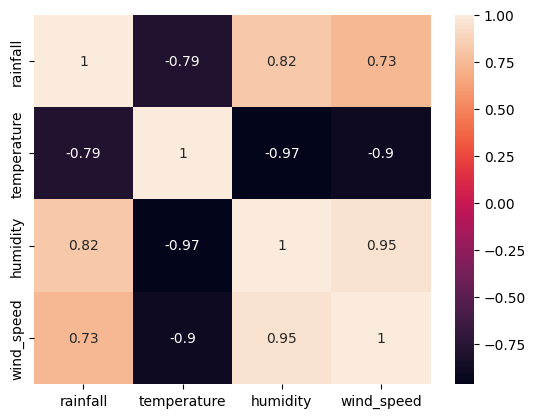

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(corr_matrix,annot=True)
plt.show()

In [ ]:
high_corr_matrix = []

for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i != j and abs(corr_matrix.loc[i, j]) > 0.8:
            high_corr_matrix.append((i, j, corr_matrix.loc[i, j]))

high_corr_matrix

[('rainfall', 'humidity', np.float64(0.8213569723603099)),
 ('temperature', 'humidity', np.float64(-0.9660971268282758)),
 ('temperature', 'wind_speed', np.float64(-0.9029958088261343)),
 ('humidity', 'rainfall', np.float64(0.8213569723603099)),
 ('humidity', 'temperature', np.float64(-0.9660971268282758)),
 ('humidity', 'wind_speed', np.float64(0.9516425912012718)),
 ('wind_speed', 'temperature', np.float64(-0.9029958088261343)),
 ('wind_speed', 'humidity', np.float64(0.9516425912012718))]

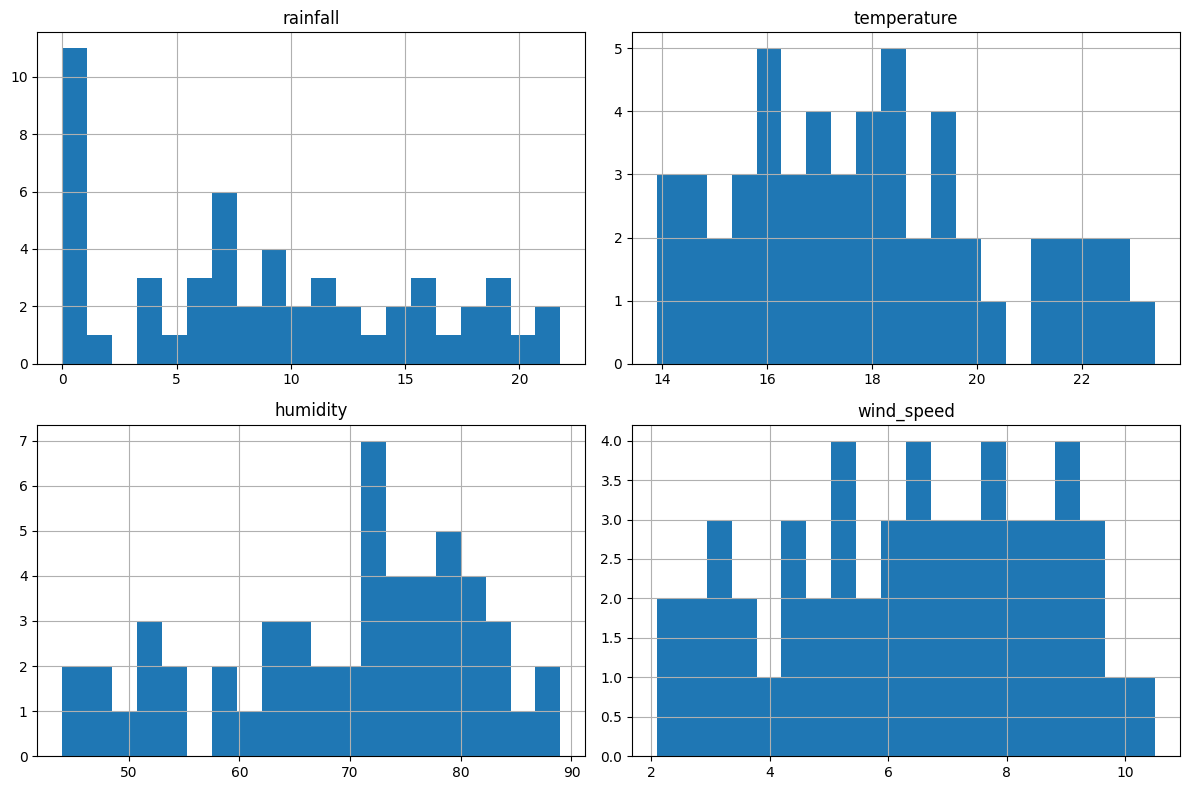

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df.hist(figsize=(12,8),bins=20 )
plt.tight_layout()
plt.show()

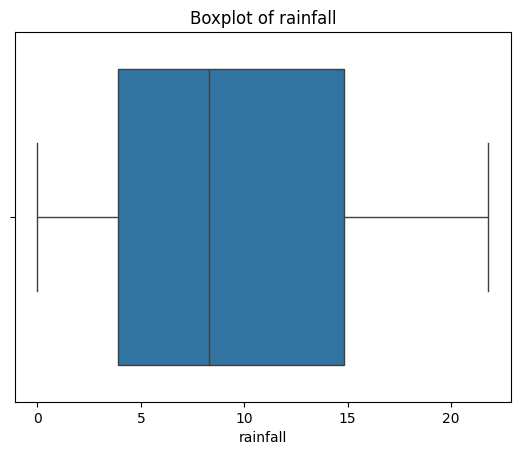

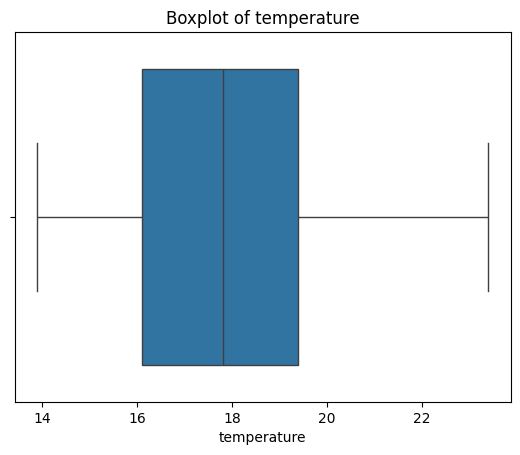

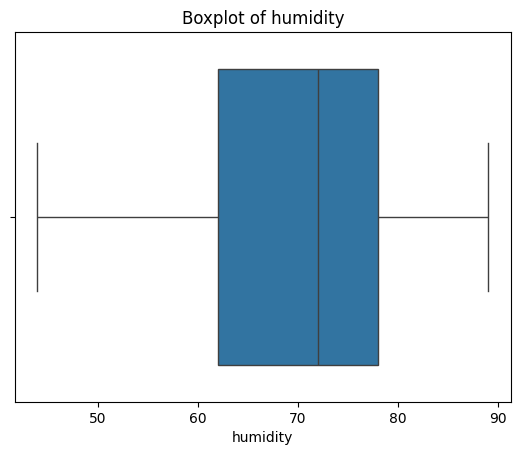

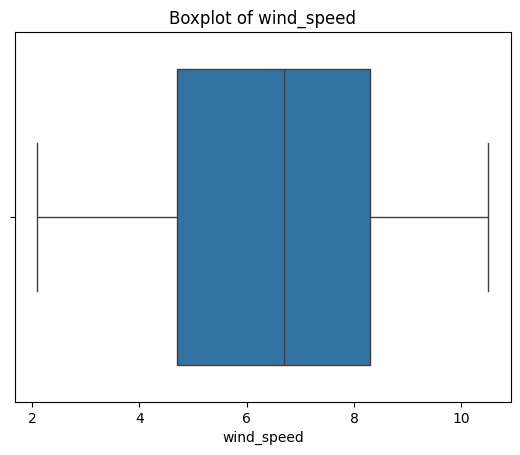

In [ ]:
import seaborn as sns

# Boxplot for each numeric column
for col in df.select_dtypes(include='number').columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()